In [1]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pip show pandas

Name: pandas
Version: 2.2.3
Summary: Powerful data structures for data analysis, time series, and statistics
Home-page: https://pandas.pydata.org
Author: 
Author-email: The Pandas Development Team <pandas-dev@python.org>
License: BSD 3-Clause License

Copyright (c) 2008-2011, AQR Capital Management, LLC, Lambda Foundry, Inc. and PyData Development Team
All rights reserved.

Copyright (c) 2011-2023, Open source contributors.

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are met:

* Redistributions of source code must retain the above copyright notice, this
  list of conditions and the following disclaimer.

* Redistributions in binary form must reproduce the above copyright notice,
  this list of conditions and the following disclaimer in the documentation
  and/or other materials provided with the distribution.

* Neither the name of the copyright holder nor the names of its
  contributors may be u

In [3]:
pip show pandas

Name: pandas
Version: 2.2.3
Summary: Powerful data structures for data analysis, time series, and statistics
Home-page: https://pandas.pydata.org
Author: 
Author-email: The Pandas Development Team <pandas-dev@python.org>
License: BSD 3-Clause License

Copyright (c) 2008-2011, AQR Capital Management, LLC, Lambda Foundry, Inc. and PyData Development Team
All rights reserved.

Copyright (c) 2011-2023, Open source contributors.

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are met:

* Redistributions of source code must retain the above copyright notice, this
  list of conditions and the following disclaimer.

* Redistributions in binary form must reproduce the above copyright notice,
  this list of conditions and the following disclaimer in the documentation
  and/or other materials provided with the distribution.

* Neither the name of the copyright holder nor the names of its
  contributors may be u

In [4]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully")

All libraries loaded successfully


In [5]:
nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [6]:
print("Total Schemes:", nav["amfi_code"].nunique())

Total Schemes: 40


In [7]:
aum = pd.read_csv("../data/processed/03_aum_by_fund_house_cleaned.csv")

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [8]:
aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


# Insight 1

Most mutual fund schemes exhibited a long-term upward NAV trend from 2022 to 2026, reflecting overall market growth despite short-term fluctuations and market corrections.

In [13]:
print("Category Inflows")
print(pd.read_csv("../data/processed/05_category_inflows_cleaned.csv").columns)

print("\nFolio Count")
print(pd.read_csv("../data/processed/06_industry_folio_count_cleaned.csv").columns)

print("\nInvestor Transactions")
print(pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv").columns)

print("\nPortfolio Holdings")
print(pd.read_csv("../data/processed/09_portfolio_holdings_cleaned.csv").columns)

Category Inflows
Index(['month', 'category', 'net_inflow_crore'], dtype='object')

Folio Count
Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='object')

Investor Transactions
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

Portfolio Holdings
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')


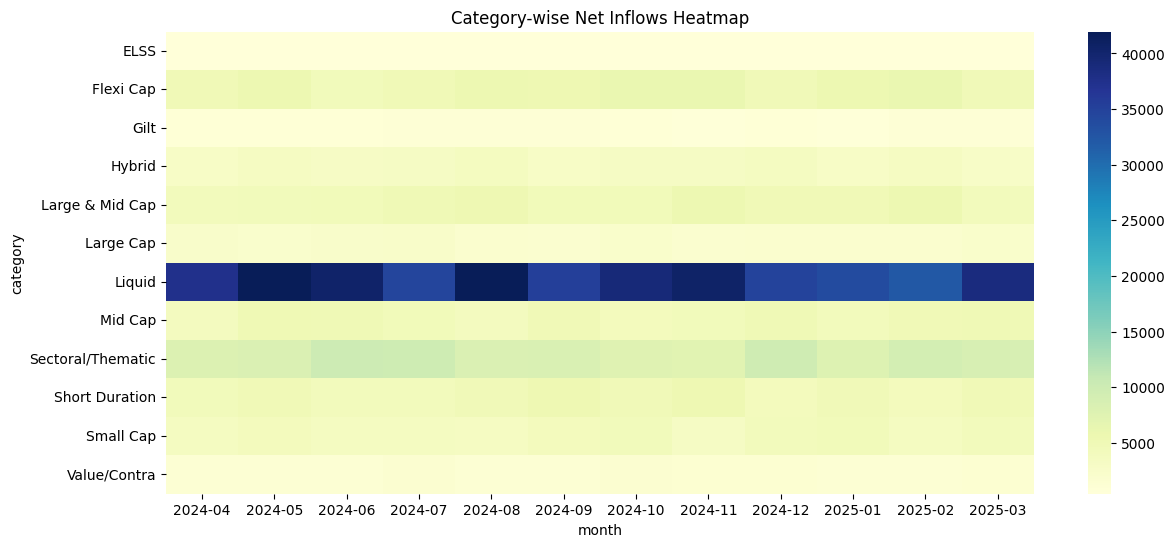

In [14]:
category = pd.read_csv("../data/processed/05_category_inflows_cleaned.csv")

heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))
sns.heatmap(heatmap_data, cmap="YlGnBu")

plt.title("Category-wise Net Inflows Heatmap")
plt.show()

# Insight 4

Equity-oriented categories consistently attracted higher inflows compared to debt categories, reflecting stronger investor preference for long-term growth investments.

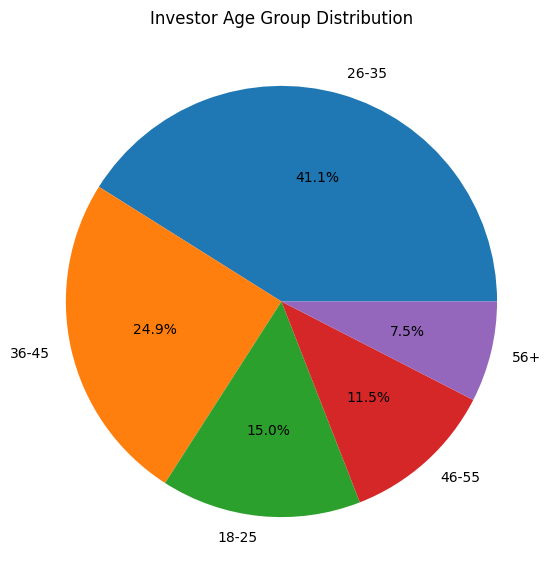

In [15]:
investors = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")

age_counts = investors["age_group"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(age_counts, labels=age_counts.index, autopct="%1.1f%%")
plt.title("Investor Age Group Distribution")
plt.show()

# Insight 5

Investors in the 25–45 age group form the largest segment of mutual fund participants, highlighting strong adoption among working professionals.

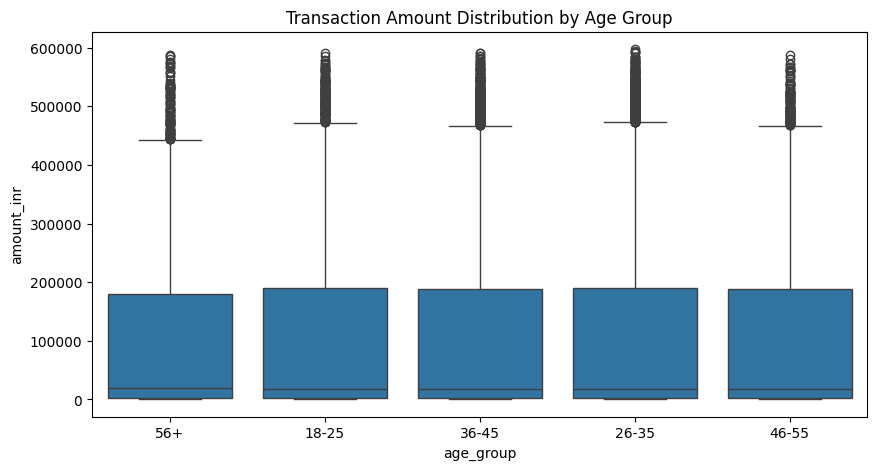

In [16]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=investors,
    x="age_group",
    y="amount_inr"
)

plt.title("Transaction Amount Distribution by Age Group")
plt.show()

# Insight 6

Middle-aged investors tend to contribute larger investment amounts, while younger investors exhibit lower but more frequent contributions.

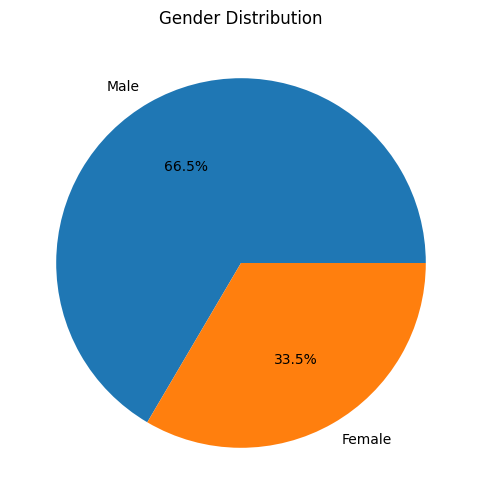

In [17]:
gender_counts = investors["gender"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")
plt.show()

# Insight 7

Male investors currently account for a larger share of mutual fund transactions, though participation from female investors continues to grow.

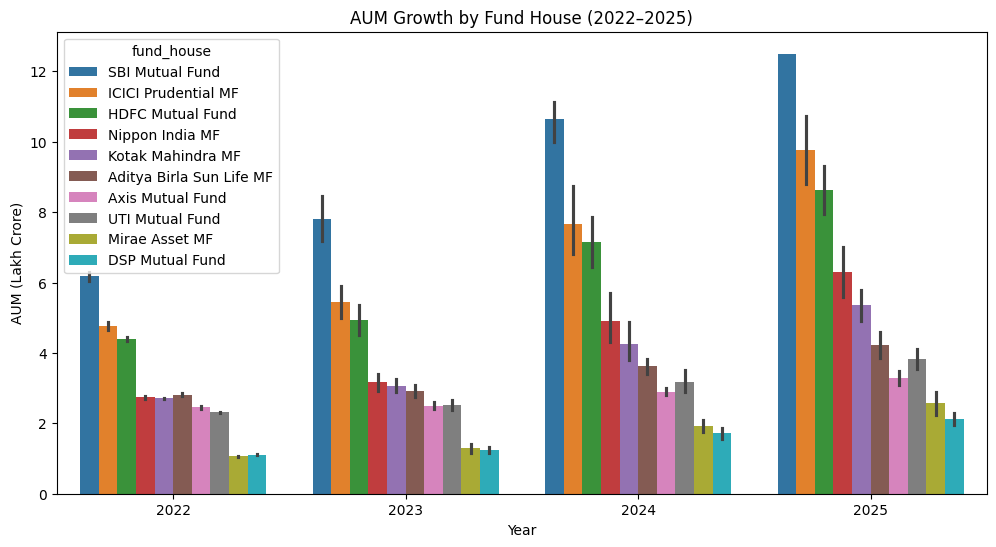

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")

plt.xticks(rotation=0)

plt.show()

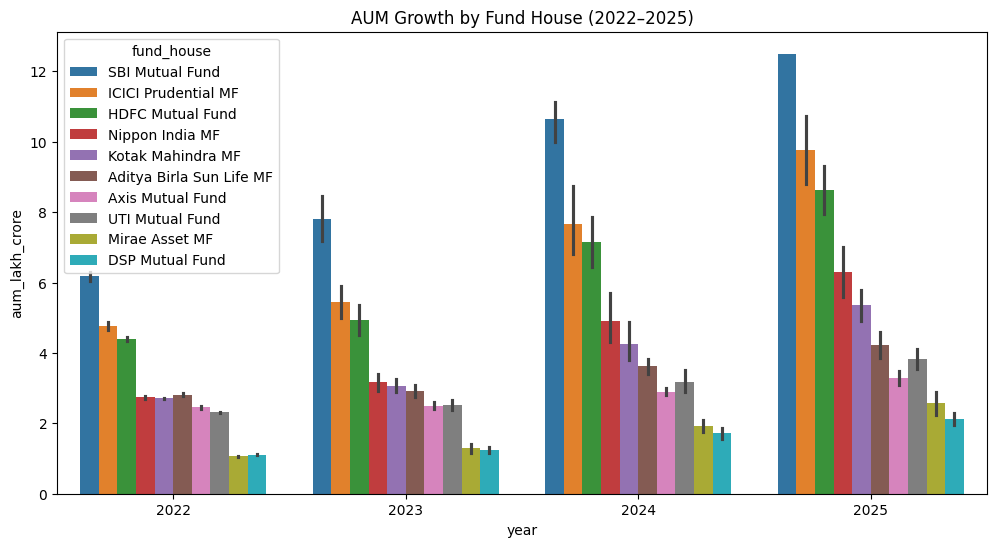

In [10]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")

plt.savefig("../reports/aum_growth.png")

plt.show()

# Insight 2

SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM) across 2022–2025, reaching approximately ₹12.5 lakh crore in 2025 and reinforcing its leadership position in the mutual fund industry.

In [11]:
sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_cleaned.csv")

print(sip.columns)

sip.head()

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [12]:
import pandas as pd
import plotly.express as px

sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_cleaned.csv")

sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (2022-2025)",
    markers=True
)

fig.show()

# Insight 3

Monthly SIP inflows increased from approximately ₹11,500 Cr in early 2022 to over ₹31,000 Cr by December 2025, indicating strong growth in retail investor participation.

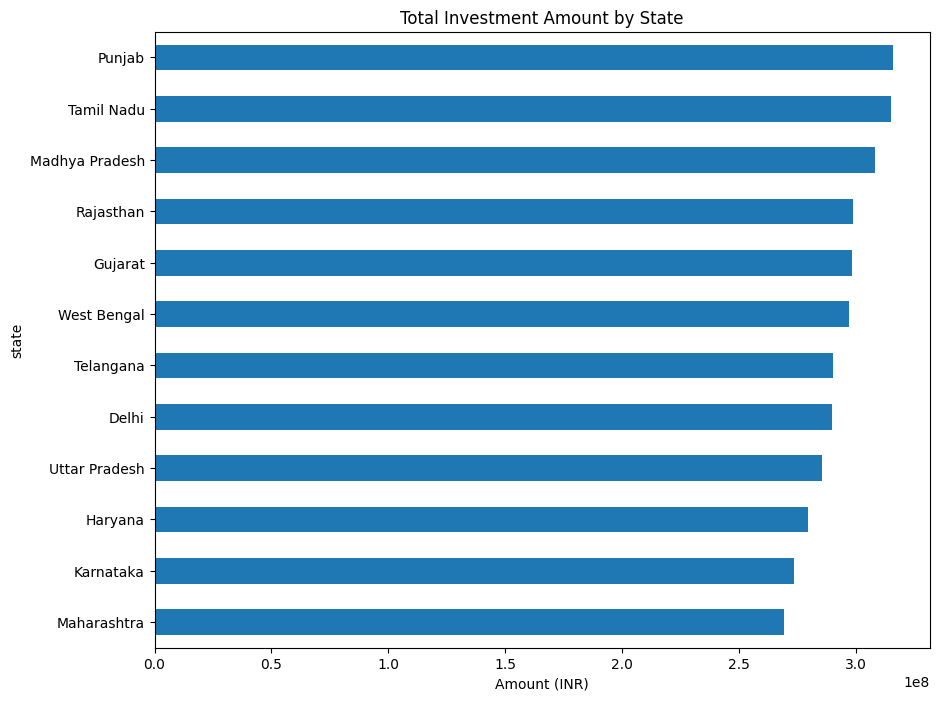

In [18]:
state_amount = investors.groupby("state")["amount_inr"].sum()

state_amount = state_amount.sort_values()

plt.figure(figsize=(10,8))

state_amount.plot(kind="barh")

plt.title("Total Investment Amount by State")
plt.xlabel("Amount (INR)")
plt.show()

# Insight 8

A small number of states contribute a significant portion of total mutual fund investments, indicating regional concentration of investor activity.

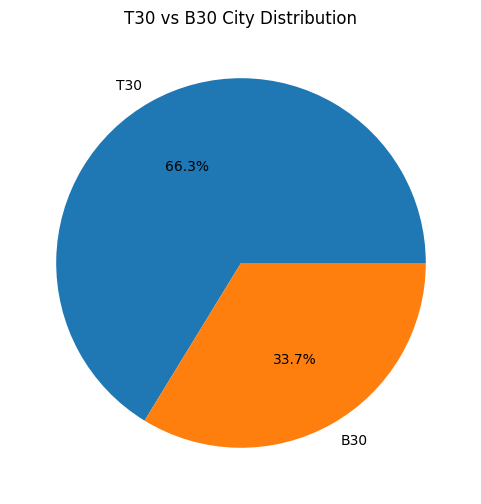

In [19]:
tier_counts = investors["city_tier"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 City Distribution")
plt.show()

# Insight 9

While T30 cities continue to dominate mutual fund participation, B30 cities are emerging as an important growth segment.

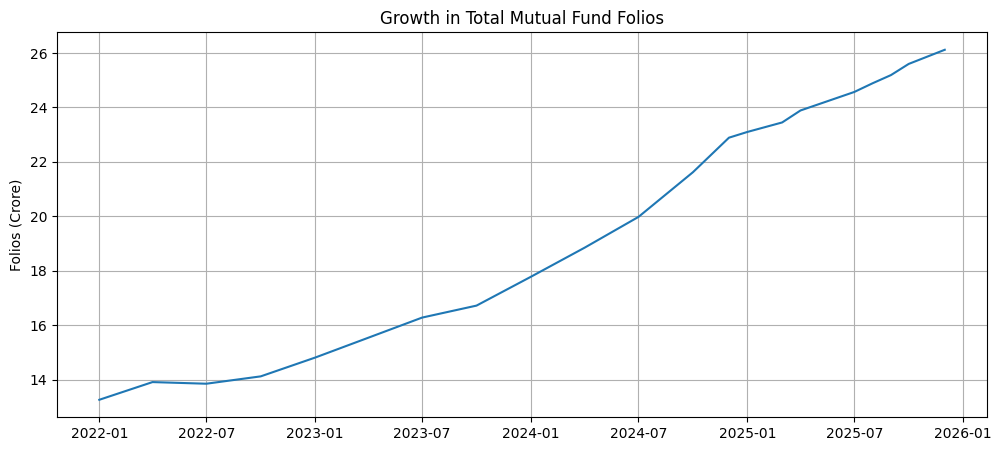

In [20]:
folio = pd.read_csv("../data/processed/06_industry_folio_count_cleaned.csv")

folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,5))

plt.plot(
    folio["month"],
    folio["total_folios_crore"]
)

plt.title("Growth in Total Mutual Fund Folios")
plt.ylabel("Folios (Crore)")
plt.grid(True)

plt.show()

# Insight 10

The total number of mutual fund folios increased steadily between 2022 and 2025, demonstrating sustained expansion of the investor base.


In [21]:
print(pd.read_csv("../data/processed/01_fund_master_cleaned.csv").columns)

print(pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv").columns)

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')


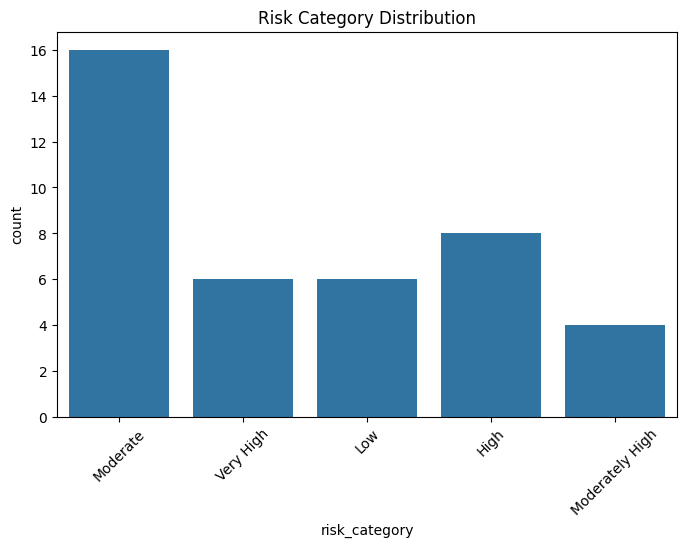

In [22]:
fund = pd.read_csv("../data/processed/01_fund_master_cleaned.csv")

plt.figure(figsize=(8,5))

sns.countplot(
    data=fund,
    x="risk_category"
)

plt.title("Risk Category Distribution")
plt.xticks(rotation=45)

plt.show()

# Insight 11

Most schemes belong to Moderate and High risk categories, indicating a strong focus on growth-oriented investment products.

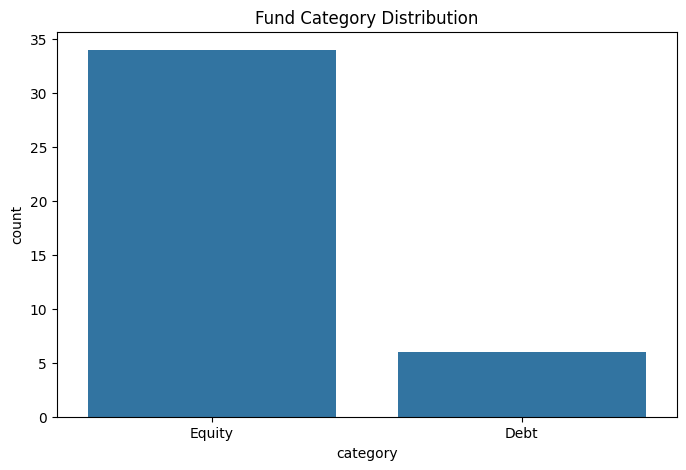

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=fund,
    x="category"
)

plt.title("Fund Category Distribution")

plt.show()

# Insight 12

Equity funds constitute the largest share of schemes, reflecting investor preference for wealth creation through equities.

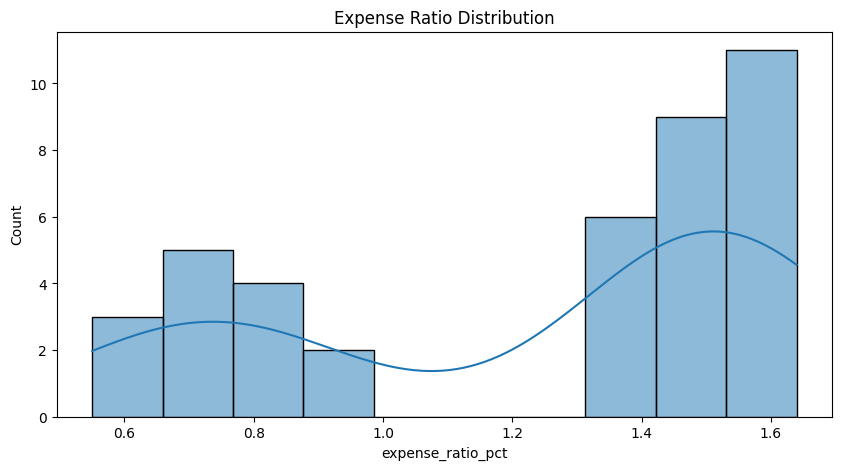

In [24]:
perf = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")

plt.figure(figsize=(10,5))

sns.histplot(
    perf["expense_ratio_pct"],
    bins=10,
    kde=True
)

plt.title("Expense Ratio Distribution")

plt.show()

# Insight 13

Most mutual fund schemes maintain expense ratios within a narrow range, ensuring competitive fund management costs.

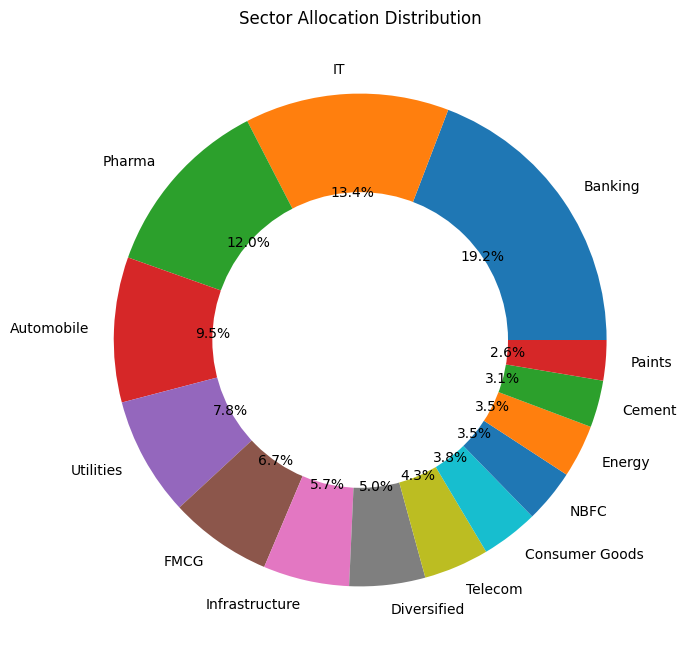

In [25]:
portfolio = pd.read_csv("../data/processed/09_portfolio_holdings_cleaned.csv")

sector_weights = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,8))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%"
)

centre_circle = plt.Circle((0,0),0.60,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation Distribution")

plt.show()

# Insight 14

Financial Services and Information Technology sectors account for a significant portion of mutual fund equity allocations.


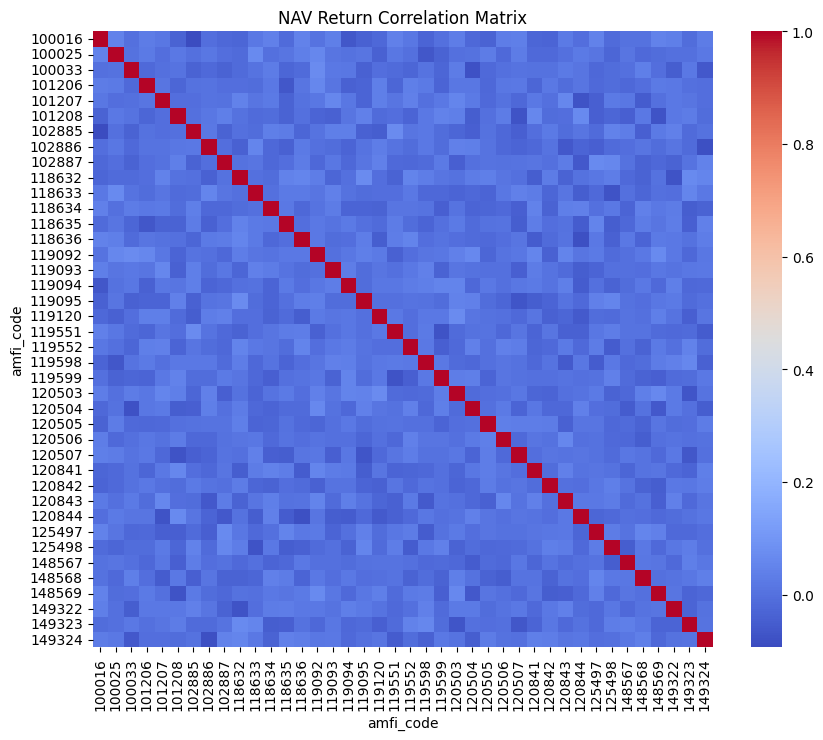

In [26]:
nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

pivot_nav = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

daily_returns = pivot_nav.pct_change()

corr_matrix = daily_returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation Matrix")

plt.show()

# Insight 15

Most large-cap and diversified equity funds exhibit positive correlations, indicating similar reactions to overall market movements.